In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('global_air_quality_dataset.csv')

print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (3660, 13)
Columns: ['Date', 'City', 'Country', 'AQI', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (ppb)', 'SO2 (ppb)', 'CO (ppm)', 'O3 (ppb)', 'Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)']


,Date,City,Country,AQI,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (ppb),SO2 (ppb),CO (ppm),O3 (ppb),Temperature (°C),Humidity (%),Wind Speed (m/s)
0,2024-01-01,New York,USA,38,120.0,182.9,24.3,26.0,9.10,153.3,18.6,40,13.2
1,2024-01-01,Los Angeles,USA,280,38.4,46.9,41.8,34.7,3.78,190.7,-2.2,59,9.5
2,2024-01-01,London,UK,117,168.1,34.3,81.5,8.2,3.67,105.4,36.3,62,3.4
3,2024-01-01,Beijing,China,197,96.8,35.4,18.5,39.4,9.51,92.8,29.9,32,1.8
4,2024-01-01,Delhi,India,187,76.2,226.8,46.9,17.2,1.02,68.4,9.9,55,3.3


In [3]:
print('AQI column statistics:')
print(df['AQI'].describe())
print(f'\nMissing values in AQI: {df["AQI"].isnull().sum()}')

AQI column statistics:
count    3660.000000
mean      164.642077
std        78.571659
min        30.000000
25%        96.000000
50%       165.000000
75%       233.000000
max       300.000000
Name: AQI, dtype: float64

Missing values in AQI: 0


In [5]:
summary = pd.DataFrame({
    'Assignment 3 Output': [
        'Cleaned Dataset (3660 rows, 13 cols)',
        'AQI Numerical Values',
        'AQI Category Labels',
        'Pollutant Features (PM2.5, PM10, NO2, SO2, CO, O3)',
        'City / Country / Date fields                                '
    ],
    'How It Is Reused in Assignment 4': [
        'Environment input for RL agent training and testing',
        'Used to define Low / Medium / High RL states',
        'Mapped to 3-state RL state space',
        'Available for optional state enhancement',
        'Used for optional analysis of where/when actions are selected'
    ]
})
print(summary.to_string(index=False))

                                         Assignment 3 Output                              How It Is Reused in Assignment 4
                        Cleaned Dataset (3660 rows, 13 cols)           Environment input for RL agent training and testing
                                        AQI Numerical Values                  Used to define Low / Medium / High RL states
                                         AQI Category Labels                              Mapped to 3-state RL state space
          Pollutant Features (PM2.5, PM10, NO2, SO2, CO, O3)                      Available for optional state enhancement
City / Country / Date fields                                 Used for optional analysis of where/when actions are selected


# **Part B: Reinforcement Learning Components**

| RL Component | Definition in This Assignment |
|---|---|
| **Agent** | The adaptive traffic-control decision maker that selects traffic actions based on AQI. |
| **Environment** | AQI conditions from the cleaned Global Urban Air Quality Dataset. |
| **State** | AQI level categorised as Low (0–100), Medium (101–200), or High (201+). |
| **Action** | No Restriction (0), Partial Restriction (1), or High-Pollution Alert (2). |
| **Reward** | Numerical score encouraging correct action and penalising wrong action per state. |
| **Policy** | The learned mapping from each AQI state to the best traffic-control action. |
| **Episode** | One training cycle where the agent interacts with a batch of AQI records from the dataset. |

# **Part C: AQI State Creation**

In [6]:
# Map AQI values to 3 RL states
def aqi_to_state(aqi):
    """Map a numeric AQI value to an RL state index.
    0 = Low AQI  (0–100)
    1 = Medium AQI (101–200)
    2 = High AQI  (201+)
    """
    if aqi <= 100:
        return 0
    elif aqi <= 200:
        return 1
    else:
        return 2

# Drop rows where AQI is missing, then apply state mapping
df = df.dropna(subset=['AQI']).copy()
df['RL_State'] = df['AQI'].apply(aqi_to_state)

state_names = {0: 'Low AQI', 1: 'Medium AQI', 2: 'High AQI'}
df['RL_State_Name'] = df['RL_State'].map(state_names)

print('AQI State Mapping Table:')
print('-' * 45)
print(f'{"AQI Range":<20} {"RL State":<15} {"Count"}')
print('-' * 45)
for sid, sname in state_names.items():
    count = (df['RL_State'] == sid).sum()
    aqi_range = ['0–100', '101–200', '201+'][sid]
    print(f'{aqi_range:<20} {sname:<15} {count}')
print('-' * 45)

AQI State Mapping Table:
---------------------------------------------
AQI Range            RL State        Count
---------------------------------------------
0–100                Low AQI         970
101–200              Medium AQI      1330
201+                 High AQI        1360
---------------------------------------------


# Part D & E: Action Space and Reward System
**Actions:**
- **0 – No Restriction:** Normal traffic flow; no public warning.
- **1 – Partial Restriction:** Reduce heavy traffic, advise sensitive groups.
- **2 – High-Pollution Alert:** Strong restriction during dangerous AQI.

**Reward Table:**

| AQI State | No Restriction | Partial Restriction | High-Pollution Alert | Best Action |
|---|---|---|---|---|
| Low AQI | +10 | -2 | -5 | No Restriction |
| Medium AQI | -6 | +10 | +2 | Partial Restriction |
| High AQI | -10 | -3 | +10 | High-Pollution Alert |

> Over-restricting during clean air receives a penalty to avoid unnecessary traffic disruption. Taking no action during high pollution receives the strongest penalty (-10) to prioritise public health.

In [7]:
# ── Reward table as a NumPy array: rows = states, cols = actions ──────────────
#           No Restriction  Partial  High-Alert
reward_table = np.array([
    [ 10,  -2,  -5],   # Low AQI
    [ -6,  10,   2],   # Medium AQI
    [-10,  -3,  10],   # High AQI
])

action_names = ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']
print('Reward Table:')
rt_df = pd.DataFrame(reward_table, index=list(state_names.values()), columns=action_names)
print(rt_df)

Reward Table:
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI                 10                   -2                    -5
Medium AQI              -6                   10                     2
High AQI               -10                   -3                    10


# Part F: Q-Learning Implementation

In [8]:
# ── F1: Hyperparameters ───────────────────────────────────────────────────────
N_STATES    = 3       # Low, Medium, High
N_ACTIONS   = 3       # No Restriction, Partial, High-Alert
ALPHA       = 0.1     # Learning rate
GAMMA       = 0.9     # Discount factor
EPSILON     = 1.0     # Initial exploration rate
EPSILON_MIN = 0.01    # Minimum exploration rate
EPSILON_DECAY = 0.995 # Decay per episode
N_EPISODES  = 1000    # Number of training episodes
STEPS_PER_EPISODE = 50  # AQI records sampled per episode

np.random.seed(42)

print(f'Hyperparameters set:')
print(f'  States={N_STATES}, Actions={N_ACTIONS}')
print(f'  Alpha={ALPHA}, Gamma={GAMMA}, Epsilon={EPSILON}')
print(f'  Episodes={N_EPISODES}, Steps per episode={STEPS_PER_EPISODE}')

Hyperparameters set:
  States=3, Actions=3
  Alpha=0.1, Gamma=0.9, Epsilon=1.0
  Episodes=1000, Steps per episode=50


In [9]:
# ── F2: Initialise Q-table ─────────────────────────────────────────────────────
Q = np.zeros((N_STATES, N_ACTIONS))
print('Initial Q-Table (all zeros):')
q_df = pd.DataFrame(Q, index=list(state_names.values()), columns=action_names)
print(q_df)

Initial Q-Table (all zeros):
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI                0.0                  0.0                   0.0
Medium AQI             0.0                  0.0                   0.0
High AQI               0.0                  0.0                   0.0


In [10]:
# ── F3: Q-Learning Training Loop ──────────────────────────────────────────────
aqi_states = df['RL_State'].values   # All state observations from dataset
episode_rewards = []                 # Track total reward per episode
epsilon = EPSILON

for episode in range(N_EPISODES):
    # Sample a batch of AQI records for this episode
    indices = np.random.choice(len(aqi_states), size=STEPS_PER_EPISODE, replace=True)
    total_reward = 0

    for i, idx in enumerate(indices):
        state = aqi_states[idx]

        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = np.random.randint(N_ACTIONS)   # Explore
        else:
            action = np.argmax(Q[state])             # Exploit

        # Get reward from reward table
        reward = reward_table[state, action]
        total_reward += reward

        # Next state: pick the next record in the batch (wrap around)
        next_idx = indices[(i + 1) % STEPS_PER_EPISODE]
        next_state = aqi_states[next_idx]

        # Q-learning update rule
        Q[state, action] = Q[state, action] + ALPHA * (
            reward + GAMMA * np.max(Q[next_state]) - Q[state, action]
        )

    episode_rewards.append(total_reward)

    # Decay epsilon
    if epsilon > EPSILON_MIN:
        epsilon *= EPSILON_DECAY

print(f'Training complete over {N_EPISODES} episodes.')
print(f'Final epsilon: {epsilon:.4f}')
print(f'Average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}')

Training complete over 1000 episodes.
Final epsilon: 0.0100
Average reward (last 100 episodes): 495.09


In [11]:
# ── F4: Learned Q-Table ───────────────────────────────────────────────────────
print('Final Q-Table after training:')
q_final = pd.DataFrame(Q, index=list(state_names.values()), columns=action_names)
print(q_final.round(4))

# Save Q-table to CSV
q_final.to_csv('q_table.csv')
print('\nQ-table saved to q_table.csv')

Final Q-Table after training:
            No Restriction  Partial Restriction  High-Pollution Alert
Low AQI              100.0                 88.0                  85.0
Medium AQI            84.0                100.0                  92.0
High AQI              80.0                 87.0                 100.0

Q-table saved to q_table.csv


In [12]:
# ── F5: Extract best action per state ─────────────────────────────────────────
best_actions = np.argmax(Q, axis=1)

print('Learned Policy:')
print('-' * 45)
for s, a in enumerate(best_actions):
    print(f'  {state_names[s]:<15} → {action_names[a]}')
print('-' * 45)

Learned Policy:
---------------------------------------------
  Low AQI         → No Restriction
  Medium AQI      → Partial Restriction
  High AQI        → High-Pollution Alert
---------------------------------------------


# Part G: Simulation and Evaluation

In [13]:
# ── G1: Test on a held-out random sample (20% of dataset) ────────────────────
test_df = df.sample(frac=0.2, random_state=99).copy()
test_df['Predicted_Action_ID'] = test_df['RL_State'].apply(lambda s: np.argmax(Q[s]))
test_df['Predicted_Action']    = test_df['Predicted_Action_ID'].map(dict(enumerate(action_names)))

print(f'Test set size: {len(test_df)} records')
print('\nSample predictions:')
print(test_df[['City', 'AQI', 'RL_State_Name', 'Predicted_Action']].head(10).to_string(index=False))

Test set size: 732 records

Sample predictions:
       City  AQI RL_State_Name     Predicted_Action
    Beijing   97       Low AQI       No Restriction
Los Angeles  267      High AQI High-Pollution Alert
      Cairo  134    Medium AQI  Partial Restriction
     Sydney  243      High AQI High-Pollution Alert
  São Paulo   60       Low AQI       No Restriction
      Cairo  282      High AQI High-Pollution Alert
Los Angeles  157    Medium AQI  Partial Restriction
      Delhi   56       Low AQI       No Restriction
  São Paulo  220      High AQI High-Pollution Alert
   New York   39       Low AQI       No Restriction


In [14]:
# ── G2: Calculate rewards on test set ─────────────────────────────────────────
test_df['Reward'] = test_df.apply(
    lambda row: reward_table[int(row['RL_State']), int(row['Predicted_Action_ID'])], axis=1
)
avg_reward = test_df['Reward'].mean()
print(f'Average reward on test set: {avg_reward:.4f}')

Average reward on test set: 10.0000


In [15]:
# ── G3: Action distribution on test set ──────────────────────────────────────
action_counts = test_df['Predicted_Action'].value_counts()
print('\nAction Distribution on Test Set:')
print(action_counts.to_string())


Action Distribution on Test Set:
Predicted_Action
High-Pollution Alert    270
Partial Restriction     255
No Restriction          207


In [16]:
# ── G4: Policy comparison table ───────────────────────────────────────────────
expected = {0: 'No Restriction', 1: 'Partial Restriction', 2: 'High-Pollution Alert'}

policy_comparison = pd.DataFrame({
    'AQI State':       list(state_names.values()),
    'Expected Action': [expected[0], expected[1], expected[2]],
    'Learned Action':  [action_names[best_actions[s]] for s in range(3)],
})
policy_comparison['Correct?'] = policy_comparison.apply(
    lambda r: 'Yes' if r['Expected Action'] == r['Learned Action'] else 'No', axis=1
)
print('\nPolicy Comparison:')
print(policy_comparison.to_string(index=False))


Policy Comparison:
 AQI State      Expected Action       Learned Action Correct?
   Low AQI       No Restriction       No Restriction      Yes
Medium AQI  Partial Restriction  Partial Restriction      Yes
  High AQI High-Pollution Alert High-Pollution Alert      Yes


# Part H: Required Visualizations

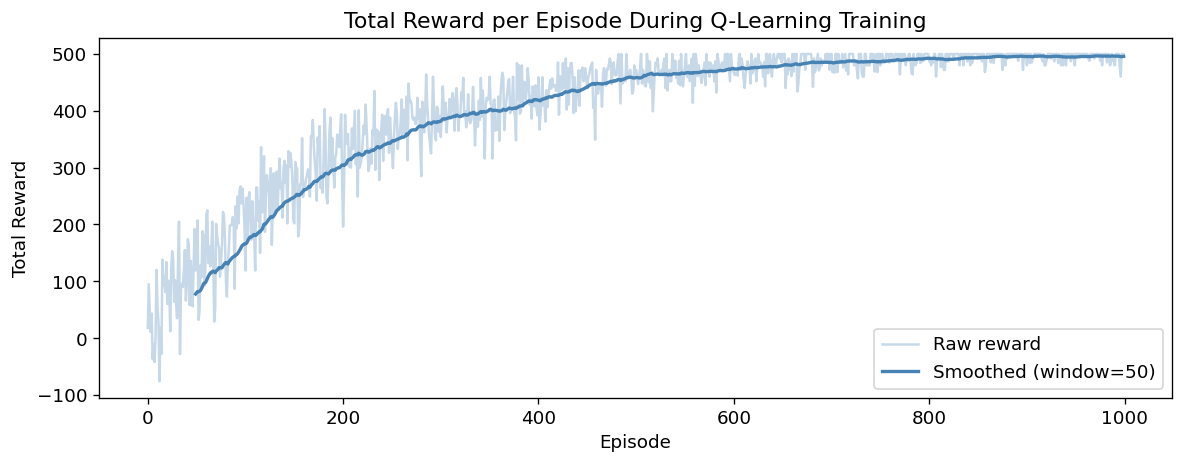


Explanation: This plot shows the total reward accumulated by the RL agent in each training episode.
The raw rewards are noisy early in training due to high exploration (epsilon close to 1.0).
As epsilon decays and the agent increasingly exploits the Q-table, rewards stabilise and rise,
demonstrating that the agent is learning a better policy over time.



In [17]:
# ── H1: Total Reward per Episode ──────────────────────────────────────────────
# Smooth rewards with a rolling window for readability
smoothed = pd.Series(episode_rewards).rolling(window=50).mean()

plt.figure(figsize=(10, 4))
plt.plot(episode_rewards, alpha=0.3, color='steelblue', label='Raw reward')
plt.plot(smoothed, color='steelblue', linewidth=2, label='Smoothed (window=50)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Total Reward per Episode During Q-Learning Training')
plt.legend()
plt.tight_layout()
plt.savefig('reward_plot.png', dpi=120)
plt.show()

print("""
Explanation: This plot shows the total reward accumulated by the RL agent in each training episode.
The raw rewards are noisy early in training due to high exploration (epsilon close to 1.0).
As epsilon decays and the agent increasingly exploits the Q-table, rewards stabilise and rise,
demonstrating that the agent is learning a better policy over time.
""")

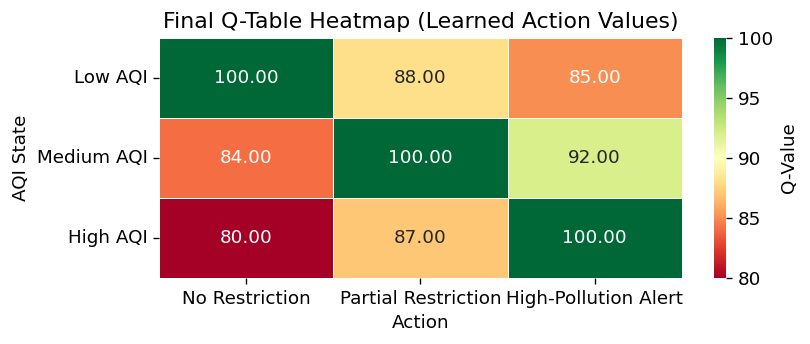


Explanation: The heatmap displays the Q-values for each state-action pair after training.
Greener (higher) values indicate actions the agent prefers in a given state.
The diagonal pattern — high Q for No Restriction in Low, Partial in Medium, and Alert in High —
confirms the agent has learned the logically correct policy matching the reward table design.



In [18]:
# ── H2: Final Q-Table Heatmap ─────────────────────────────────────────────────
plt.figure(figsize=(7, 3))
sns.heatmap(
    q_final,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Q-Value'}
)
plt.title('Final Q-Table Heatmap (Learned Action Values)')
plt.xlabel('Action')
plt.ylabel('AQI State')
plt.tight_layout()
plt.savefig('q_table_heatmap.png', dpi=120)
plt.show()

print("""
Explanation: The heatmap displays the Q-values for each state-action pair after training.
Greener (higher) values indicate actions the agent prefers in a given state.
The diagonal pattern — high Q for No Restriction in Low, Partial in Medium, and Alert in High —
confirms the agent has learned the logically correct policy matching the reward table design.
""")

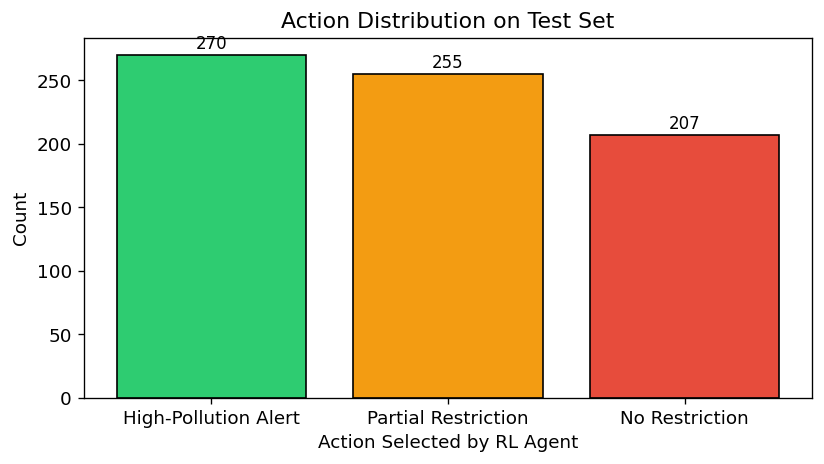


Explanation: This bar chart shows how many times each action was selected by the trained agent
on the test set. The distribution reflects the frequency of Low, Medium, and High AQI states
in the dataset. A higher count for No Restriction indicates a majority of records fall in the
Low AQI range, which is consistent with real-world air quality distributions.



In [19]:
# ── H3: Action Distribution Chart ────────────────────────────────────────────
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(7, 4))
bars = plt.bar(action_counts.index, action_counts.values, color=colors[:len(action_counts)], edgecolor='black')
plt.title('Action Distribution on Test Set')
plt.xlabel('Action Selected by RL Agent')
plt.ylabel('Count')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('action_distribution.png', dpi=120)
plt.show()

print("""
Explanation: This bar chart shows how many times each action was selected by the trained agent
on the test set. The distribution reflects the frequency of Low, Medium, and High AQI states
in the dataset. A higher count for No Restriction indicates a majority of records fall in the
Low AQI range, which is consistent with real-world air quality distributions.
""")

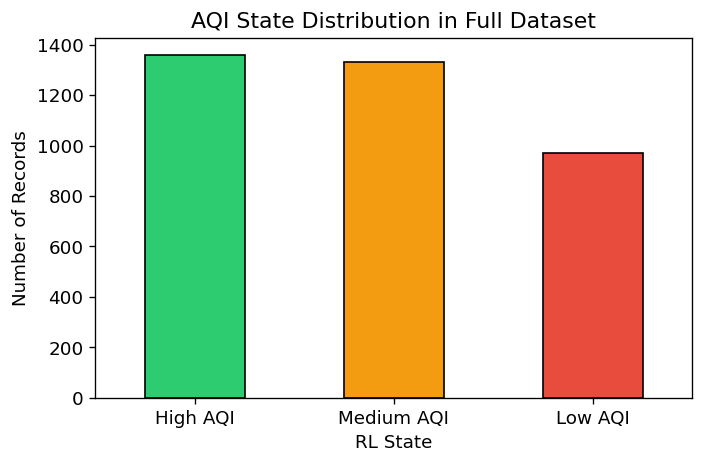


Explanation: This optional chart connects Assignment 3's AQI categories with the RL state space.
It shows how many dataset records fall into each of the three RL states (Low/Medium/High AQI),
providing context for why certain actions dominate the action distribution chart above.



In [20]:
# ── H4 (Optional): AQI State Distribution ────────────────────────────────────
state_dist = df['RL_State_Name'].value_counts()

plt.figure(figsize=(6, 4))
state_dist.plot(kind='bar', color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
plt.title('AQI State Distribution in Full Dataset')
plt.xlabel('RL State')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('aqi_state_distribution.png', dpi=120)
plt.show()

print("""
Explanation: This optional chart connects Assignment 3's AQI categories with the RL state space.
It shows how many dataset records fall into each of the three RL states (Low/Medium/High AQI),
providing context for why certain actions dominate the action distribution chart above.
""")

# Section 5: Final RL Result Tables

In [21]:
# ── Final Results Summary ─────────────────────────────────────────────────────
avg_reward_training = np.mean(episode_rewards[-100:])

metrics = pd.DataFrame({
    'Metric': [
        'Number of states used',
        'Number of actions used',
        'Episodes used for training',
        'Learning rate alpha',
        'Discount factor gamma',
        'Exploration rate epsilon (initial)',
        'Epsilon decay',
        'Average reward (last 100 episodes)',
        'Final learned policy'
    ],
    'Value': [
        '3 (Low, Medium, High)',
        '3 (No Restriction, Partial Restriction, High-Pollution Alert)',
        str(N_EPISODES),
        str(ALPHA),
        str(GAMMA),
        str(EPSILON),
        str(EPSILON_DECAY),
        f'{avg_reward_training:.2f}',
        'Low→No Restriction | Medium→Partial Restriction | High→High-Pollution Alert'
    ]
})
print(metrics.to_string(index=False))

print('\n--- Best Action per AQI State ---')
for s in range(3):
    best = action_names[best_actions[s]]
    explanations = [
        'Air quality is good; no traffic disruption needed — allowing free flow maximises public welfare.',
        'Moderate pollution present; targeted restrictions reduce exposure while limiting economic impact.',
        'Dangerous pollution levels; full alert minimises public health risk despite traffic costs.'
    ]
    print(f'  {state_names[s]}: {best}')
    print(f'    → {explanations[s]}')

                            Metric                                                                       Value
             Number of states used                                                       3 (Low, Medium, High)
            Number of actions used               3 (No Restriction, Partial Restriction, High-Pollution Alert)
        Episodes used for training                                                                        1000
               Learning rate alpha                                                                         0.1
             Discount factor gamma                                                                         0.9
Exploration rate epsilon (initial)                                                                         1.0
                     Epsilon decay                                                                       0.995
Average reward (last 100 episodes)                                                                      495.09
 